In [1]:
%pip install sacrebleu --quiet


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [1]:
import os, time, random, math, json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import sacrebleu as sb
from tqdm.auto import tqdm
from collections import Counter


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

device: cuda


## Конфиг

In [ ]:
DATA_DIR = "data"

MIN_FREQ = 2
MAX_LENGTH = 50

D_MODEL = 256
N_HEADS = 8
D_FF = 512 # 1024 не помогло + увеличение эпох до 20 тоже + beam search
NUM_ENC_LAYERS = 3
NUM_DEC_LAYERS = 3
DROPOUT = 0.1

BATCH_SIZE = 256
NUM_EPOCHS = 15
LEARNING_RATE = 3e-4
GRAD_CLIP = 1.0
WARMUP_STEPS = 4000
LABEL_SMOOTHING = 0.1

SAVE_PATH = "best_transformer.pt"
OUTPUT_FILE = "test1.de-en.en"

## Скачивание данных

In [ ]:
import glob, shutil

FILE_ID = "1hvU16vYvncpg4OSeveDxWbKSOgqrcVU4"
os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(os.path.join(DATA_DIR, "train.de-en.de")):
    import urllib.request
    url = f"https://drive.google.com/uc?export=download&id={FILE_ID}"
    urllib.request.urlretrieve(url, "data.zip")
    import zipfile
    with zipfile.ZipFile("data.zip", "r") as z:
        z.extractall(".")
    for f in glob.glob("data/data/*"):
        shutil.move(f, DATA_DIR)
    if os.path.isdir("data/data"):
        os.rmdir("data/data")
    print("данные скачаны")
else:
    print("данные на месте")

for f in sorted(os.listdir(DATA_DIR)):
    path = os.path.join(DATA_DIR, f)
    if os.path.isfile(path):
        lines = sum(1 for _ in open(path))
        print(f"  {f}: {lines} lines")

## Dataset & Vocabulary

In [3]:
PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN = "<pad>", "<sos>", "<eos>", "<unk>"
SPECIALS = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN]
PAD_IDX, SOS_IDX, EOS_IDX, UNK_IDX = 0, 1, 2, 3


class Vocabulary:
    def __init__(self, min_freq=2):
        self.min_freq = min_freq
        self.word2idx = {}
        self.idx2word = []
        self.word_count = Counter()

    def build(self, sentences):
        for sent in sentences:
            self.word_count.update(sent)
        self.idx2word = list(SPECIALS)
        self.word2idx = {tok: i for i, tok in enumerate(SPECIALS)}
        for word, count in self.word_count.most_common():
            if count >= self.min_freq:
                self.word2idx[word] = len(self.idx2word)
                self.idx2word.append(word)

    def encode(self, tokens):
        return [self.word2idx.get(t, UNK_IDX) for t in tokens]

    def decode(self, indices):
        return [self.idx2word[i] if i < len(self.idx2word) else UNK_TOKEN for i in indices]

    def __len__(self):
        return len(self.idx2word)


class TranslationDataset(Dataset):
    def __init__(self, src_file, trg_file=None, src_vocab=None, trg_vocab=None,
                 min_freq=2, max_length=100):
        self.max_length = max_length
        with open(src_file, "r", encoding="utf-8") as f:
            self.src_sentences = [line.strip().split() for line in f if line.strip()]
        self.trg_sentences = None
        if trg_file is not None:
            with open(trg_file, "r", encoding="utf-8") as f:
                self.trg_sentences = [line.strip().split() for line in f if line.strip()]
            assert len(self.src_sentences) == len(self.trg_sentences)
        if src_vocab is None:
            self.src_vocab = Vocabulary(min_freq)
            self.src_vocab.build(self.src_sentences)
        else:
            self.src_vocab = src_vocab
        if trg_vocab is None and self.trg_sentences is not None:
            self.trg_vocab = Vocabulary(min_freq)
            self.trg_vocab.build(self.trg_sentences)
        else:
            self.trg_vocab = trg_vocab

    def __len__(self):
        return len(self.src_sentences)

    def __getitem__(self, idx):
        src_tokens = self.src_sentences[idx][:self.max_length]
        src_indices = [SOS_IDX] + self.src_vocab.encode(src_tokens) + [EOS_IDX]
        src_tensor = torch.tensor(src_indices, dtype=torch.long)
        if self.trg_sentences is not None:
            trg_tokens = self.trg_sentences[idx][:self.max_length]
            trg_indices = [SOS_IDX] + self.trg_vocab.encode(trg_tokens) + [EOS_IDX]
            trg_tensor = torch.tensor(trg_indices, dtype=torch.long)
            return src_tensor, trg_tensor
        return src_tensor


def collate_fn(batch):
    if isinstance(batch[0], tuple):
        src_batch, trg_batch = zip(*batch)
        src_lens = torch.tensor([len(s) for s in src_batch])
        trg_lens = torch.tensor([len(t) for t in trg_batch])
        src_padded = pad_sequence(src_batch, batch_first=True, padding_value=PAD_IDX)
        trg_padded = pad_sequence(trg_batch, batch_first=True, padding_value=PAD_IDX)
        return src_padded, trg_padded, src_lens, trg_lens
    else:
        src_lens = torch.tensor([len(s) for s in batch])
        src_padded = pad_sequence(batch, batch_first=True, padding_value=PAD_IDX)
        return src_padded, src_lens

## Загрузка данных

In [4]:
train_dataset = TranslationDataset(
    src_file=os.path.join(DATA_DIR, "train.de-en.de"),
    trg_file=os.path.join(DATA_DIR, "train.de-en.en"),
    min_freq=MIN_FREQ, max_length=MAX_LENGTH,
)
val_dataset = TranslationDataset(
    src_file=os.path.join(DATA_DIR, "val.de-en.de"),
    trg_file=os.path.join(DATA_DIR, "val.de-en.en"),
    src_vocab=train_dataset.src_vocab,
    trg_vocab=train_dataset.trg_vocab,
    max_length=MAX_LENGTH,
)
test_dataset = TranslationDataset(
    src_file=os.path.join(DATA_DIR, "test1.de-en.de"),
    trg_file=None,
    src_vocab=train_dataset.src_vocab,
    max_length=MAX_LENGTH,
)
test_dataset.trg_vocab = train_dataset.trg_vocab

print(f"Source vocab: {len(train_dataset.src_vocab)}")
print(f"Target vocab: {len(train_dataset.trg_vocab)}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

Source vocab: 55315
Target vocab: 34047
Train: 195915 | Val: 986 | Test: 2998


## Transformer модель

In [5]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)


class TransformerSeq2Seq(nn.Module):
    def __init__(self, src_vocab_size, trg_vocab_size, d_model, nhead,
                 num_encoder_layers, num_decoder_layers, dim_feedforward, dropout):
        super().__init__()
        self.d_model = d_model
        self.src_embedding = nn.Embedding(src_vocab_size, d_model, padding_idx=PAD_IDX)
        self.trg_embedding = nn.Embedding(trg_vocab_size, d_model, padding_idx=PAD_IDX)
        self.pos_encoder = PositionalEncoding(d_model, dropout=dropout)
        self.transformer = nn.Transformer(
            d_model=d_model, nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True,
        )
        self.fc_out = nn.Linear(d_model, trg_vocab_size)
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, src, trg):
        src_key_padding_mask = (src == PAD_IDX)
        trg_key_padding_mask = (trg == PAD_IDX)
        trg_mask = nn.Transformer.generate_square_subsequent_mask(trg.size(1), device=src.device)
        src_emb = self.pos_encoder(self.src_embedding(src) * math.sqrt(self.d_model))
        trg_emb = self.pos_encoder(self.trg_embedding(trg) * math.sqrt(self.d_model))
        output = self.transformer(
            src_emb, trg_emb,
            tgt_mask=trg_mask,
            src_key_padding_mask=src_key_padding_mask,
            tgt_key_padding_mask=trg_key_padding_mask,
            memory_key_padding_mask=src_key_padding_mask,
        )
        return self.fc_out(output)

    @torch.inference_mode()
    def translate(self, src, max_length=128):
        self.eval()
        batch_size = src.size(0)
        src_key_padding_mask = (src == PAD_IDX)
        src_emb = self.pos_encoder(self.src_embedding(src) * math.sqrt(self.d_model))
        memory = self.transformer.encoder(src_emb, src_key_padding_mask=src_key_padding_mask)
        ys = torch.full((batch_size, 1), SOS_IDX, dtype=torch.long, device=src.device)
        finished = torch.zeros(batch_size, dtype=torch.bool, device=src.device)
        for _ in range(max_length):
            trg_emb = self.pos_encoder(self.trg_embedding(ys) * math.sqrt(self.d_model))
            trg_mask = nn.Transformer.generate_square_subsequent_mask(ys.size(1), device=src.device)
            output = self.transformer.decoder(
                trg_emb, memory,
                tgt_mask=trg_mask,
                memory_key_padding_mask=src_key_padding_mask,
            )
            next_logits = self.fc_out(output[:, -1])
            next_token = next_logits.argmax(dim=-1)
            finished = finished | (next_token == EOS_IDX)
            ys = torch.cat([ys, next_token.unsqueeze(1)], dim=1)
            if finished.all():
                break
        decoded = []
        for i in range(batch_size):
            tokens = ys[i, 1:].tolist()
            try:
                eos_pos = tokens.index(EOS_IDX)
                tokens = tokens[:eos_pos]
            except ValueError:
                pass
            decoded.append(tokens)
        return decoded

## Создание модели

In [6]:
model = TransformerSeq2Seq(
    src_vocab_size=len(train_dataset.src_vocab),
    trg_vocab_size=len(train_dataset.trg_vocab),
    d_model=D_MODEL, nhead=N_HEADS,
    num_encoder_layers=NUM_ENC_LAYERS,
    num_decoder_layers=NUM_DEC_LAYERS,
    dim_feedforward=D_FF, dropout=DROPOUT,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Transformer params: {n_params:,}")

Transformer params: 37,157,375


## Обучение

In [17]:
def train_epoch(model, loader, optimizer, criterion, grad_clip, scheduler=None):
    model.train()
    total_loss = 0
    for batch in tqdm(loader, desc="Train"):
        src, trg, _, _ = batch
        src, trg = src.to(device), trg.to(device)
        optimizer.zero_grad()
        output = model(src, trg[:, :-1])
        output = output.reshape(-1, output.size(-1))
        target = trg[:, 1:].reshape(-1)
        loss = criterion(output, target)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        if scheduler is not None:
            scheduler.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in tqdm(loader, desc="Val"):
            src, trg, _, _ = batch
            src, trg = src.to(device), trg.to(device)
            output = model(src, trg[:, :-1])
            output = output.reshape(-1, output.size(-1))
            target = trg[:, 1:].reshape(-1)
            loss = criterion(output, target)
            total_loss += loss.item()
    return total_loss / len(loader)


def translate_dataset(model, loader, trg_vocab):
    model.eval()
    translations = []
    with torch.no_grad():
        for batch in tqdm(loader, desc="Translate"):
            if isinstance(batch, tuple) and len(batch) == 4:
                src = batch[0].to(device)
            else:
                src = batch[0].to(device)
            decoded = model.translate(src)
            for token_ids in decoded:
                tokens = trg_vocab.decode(token_ids)
                translations.append(" ".join(tokens))
    return translations


def compute_bleu(translations, references):
    return sb.corpus_bleu(translations, [references], tokenize="none").score

## Тренировочный цикл

In [18]:
import warnings
warnings.filterwarnings("ignore")

In [10]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=LABEL_SMOOTHING)
optimizer = torch.optim.Adam(model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)

def noam_schedule(step):
    step = max(step, 1)
    return (D_MODEL ** -0.5) * min(step ** -0.5, step * WARMUP_STEPS ** -1.5)

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, noam_schedule)

val_references = [" ".join(s) for s in val_dataset.trg_sentences]
best_bleu = -1.0


history = {"train_loss": [], "val_loss": [], "bleu": [], "ppl": [], "lr": []}

for epoch in range(1, NUM_EPOCHS + 1):
    start = time.time()
    train_loss = train_epoch(model, train_loader, optimizer, criterion, GRAD_CLIP, scheduler)
    val_loss = evaluate(model, val_loader, criterion)
    elapsed = time.time() - start

    translations = translate_dataset(model, val_loader, train_dataset.trg_vocab)
    bleu_score = compute_bleu(translations, val_references)

    lr = optimizer.param_groups[0]["lr"]
    
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["bleu"].append(bleu_score)
    history["ppl"].append(math.exp(val_loss))
    history["lr"].append(lr)

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | LR: {lr:.6f} | "
          f"Train: {train_loss:.4f} | Val: {val_loss:.4f} | "
          f"PPL: {math.exp(val_loss):.2f} | BLEU: {bleu_score:.2f} | {elapsed:.0f}s")

    for i in range(min(3, len(translations))):
        print(f"HYP: {translations[i]}")
        print(f"REF: {val_references[i]}")
        print()

    if bleu_score > best_bleu:
        best_bleu = bleu_score
        torch.save({"epoch": epoch, "model_state_dict": model.state_dict(),
                     "optimizer_state_dict": optimizer.state_dict(),
                     "bleu": best_bleu, "val_loss": val_loss}, SAVE_PATH)
        print(f"best BLEU: {best_bleu:.2f} saved!")

print(f"\n best BLEU: {best_bleu:.2f}")


Translate: 100%|██████████| 4/4 [00:01<00:00,  2.38it/s]
That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


Epoch 01/15 | LR: 0.000189 | Train: 4.1212 | Val: 3.8926 | PPL: 49.04 | BLEU: 20.04 | 128s
HYP: when i was 11 years old , i was a picture of the music of the sounds .
REF: when i was 11 , i remember waking up one morning to the sound of joy in my house .

HYP: my father heard on his little , dark , the <unk> , the <unk> of the table .
REF: my father was listening to bbc news on his small , gray radio .

HYP: he looked very happy , which was pretty unusual , because it was the news of the news .
REF: there was a big smile on his face which was unusual then , because the news mostly depressed him .

best BLEU: 20.04 saved!


Translate: 100%|██████████| 4/4 [00:01<00:00,  2.37it/s]
That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


Epoch 02/15 | LR: 0.000378 | Train: 3.9471 | Val: 3.7183 | PPL: 41.19 | BLEU: 22.86 | 128s
HYP: when i was 11 years old , i became a second piece of joy of the sound .
REF: when i was 11 , i remember waking up one morning to the sound of joy in my house .

HYP: my father heard on his little , gray , the <unk> of the <unk> of the fourth .
REF: my father was listening to bbc news on his small , gray radio .

HYP: he looked very happy , which was pretty unusual , because it was most important .
REF: there was a big smile on his face which was unusual then , because the news mostly depressed him .

best BLEU: 22.86 saved!


Translate: 100%|██████████| 4/4 [00:01<00:00,  2.38it/s]
That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


...

Epoch 13/15 | LR: 0.000626 | Train: 2.7237 | Val: 3.3312 | PPL: 27.97 | BLEU: 30.97 | 128s
HYP: when i was 11 years old , i 'd been caught one morning by the sound of the sounds .
REF: when i was 11 , i remember waking up one morning to the sound of joy in my house .

HYP: my father heard about his little , gray radio , <unk> on the <unk> .
REF: my father was listening to bbc news on his small , gray radio .

HYP: he looked very happy , which was quite unusual , because it was the news most frequently .
REF: there was a big smile on his face which was unusual then , because the news mostly depressed him .

best BLEU: 30.97 saved!


Translate: 100%|██████████| 4/4 [00:01<00:00,  2.38it/s]
That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


Epoch 14/15 | LR: 0.000604 | Train: 2.6802 | Val: 3.3519 | PPL: 28.56 | BLEU: 30.95 | 127s
HYP: when i was 11 , i was able to get a bright pair of pleasure coming out of the sound .
REF: when i was 11 , i remember waking up one morning to the sound of joy in my house .

HYP: my father listened to his little , gray , radio , <unk> on the <unk> of the bbc .
REF: my father was listening to bbc news on his small , gray radio .

HYP: he looked very happy , which was pretty unusual at the time , because the news was mostly about it .
REF: there was a big smile on his face which was unusual then , because the news mostly depressed him .



Translate: 100%|██████████| 4/4 [00:01<00:00,  2.36it/s]
That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


Epoch 15/15 | LR: 0.000583 | Train: 2.6403 | Val: 3.3665 | PPL: 28.98 | BLEU: 31.08 | 128s
HYP: when i was 11 years old , i was introduced one morning by the sound of the sound .
REF: when i was 11 , i remember waking up one morning to the sound of joy in my house .

HYP: my dad heard on his little , gray , radio , the <unk> of the bbc ,
REF: my father was listening to bbc news on his small , gray radio .

HYP: he looked very happy , which was quite unusual at the time , because it was the news mostly .
REF: there was a big smile on his face which was unusual then , because the news mostly depressed him .

best BLEU: 31.08 saved!

 best BLEU: 31.08


### визуализация 

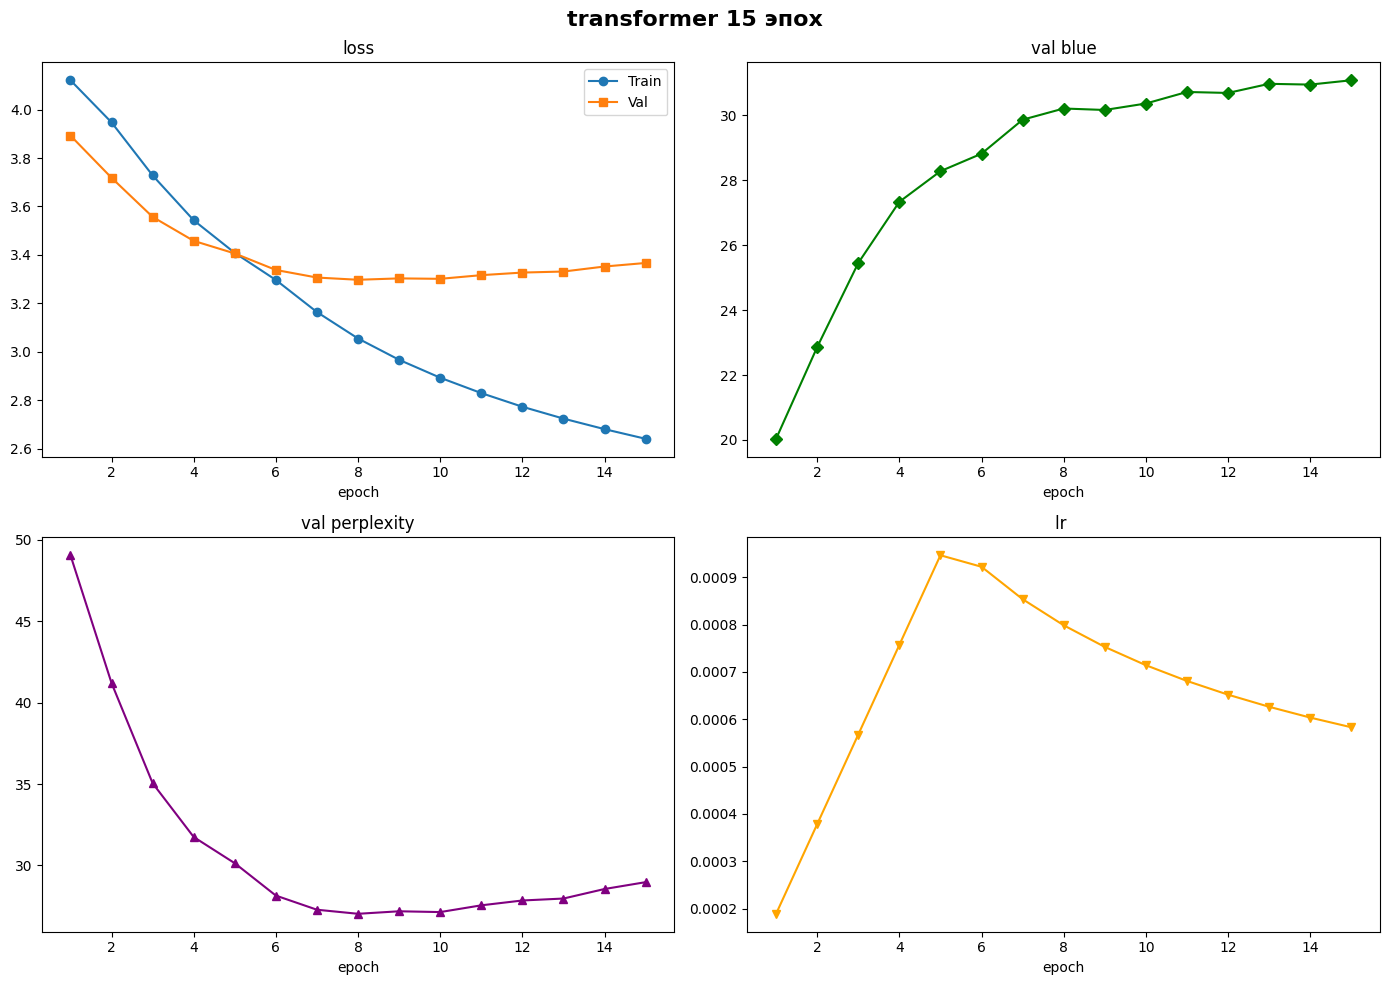

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'transformer {NUM_EPOCHS} эпох', fontsize=16, fontweight='bold')
epochs = list(range(1, len(history["train_loss"]) + 1))

axes[0,0].plot(epochs, history["train_loss"], 'o-', label='Train'); axes[0,0].plot(epochs, history["val_loss"], 's-', label='Val')
axes[0,0].set_title('loss'); axes[0,0].legend(); axes[0,0].set_xlabel('epoch')

axes[0,1].plot(epochs, history["bleu"], 'D-', color='green')
axes[0,1].set_title('val blue'); axes[0,1].set_xlabel('epoch')

axes[1,0].plot(epochs, history["ppl"], '^-', color='purple')
axes[1,0].set_title('val perplexity'); axes[1,0].set_xlabel('epoch')

axes[1,1].plot(epochs, history["lr"], 'v-', color='orange')
axes[1,1].set_title('lr '); axes[1,1].set_xlabel('epoch')

plt.tight_layout()
plt.savefig('transformer_training.png', dpi=150, bbox_inches='tight')
plt.show()


## Перевод тестовой выборки

In [12]:
ckpt = torch.load(SAVE_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
print(f"Loaded best model: epoch {ckpt['epoch']}, BLEU {ckpt['bleu']:.2f}")

test_translations = translate_dataset(model, test_loader, train_dataset.trg_vocab)
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    for line in test_translations:
        f.write(line + "\n")
print(f"wrote {len(test_translations)} translations to {OUTPUT_FILE}")

val_references = [" ".join(s) for s in val_dataset.trg_sentences]
val_translations = translate_dataset(model, val_loader, train_dataset.trg_vocab)
final_bleu = compute_bleu(val_translations, val_references)
print(f"final validation BLEU: {final_bleu:.2f}")

for i in range(min(5, len(val_translations))):
    print(f"SRC: {' '.join(val_dataset.src_sentences[i])}")
    print(f"HYP: {val_translations[i]}")
    print(f"REF: {val_references[i]}")
    print()

Loaded best model: epoch 15, BLEU 31.08


Translate: 100%|██████████| 12/12 [00:05<00:00,  2.39it/s]


wrote 2998 translations to test1.de-en.en


Translate: 100%|██████████| 4/4 [00:01<00:00,  2.36it/s]
That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


final validation BLEU: 31.08
SRC: als ich 11 jahre alt war , wurde ich eines morgens von den klängen heller freude geweckt .
HYP: when i was 11 years old , i was introduced one morning by the sound of the sound .
REF: when i was 11 , i remember waking up one morning to the sound of joy in my house .

SRC: mein vater hörte sich auf seinem kleinen , grauen radio die nachrichtensendung der bbc an .
HYP: my dad heard on his little , gray , radio , the <unk> of the bbc ,
REF: my father was listening to bbc news on his small , gray radio .

SRC: er sah sehr glücklich aus , was damals ziemlich ungewöhnlich war , da ihn die nachrichten meistens deprimierten .
HYP: he looked very happy , which was quite unusual at the time , because it was the news mostly .
REF: there was a big smile on his face which was unusual then , because the news mostly depressed him .

SRC: er rief : " die taliban sind weg ! "
HYP: he called , " the taliban are gone ! "
REF: " the taliban are gone ! " my father shouted 

In [23]:
ckpt = torch.load(SAVE_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])

<All keys matched successfully>

In [26]:
# beam search для трансформера
@torch.inference_mode()
def beam_search_translate(model, src, beam_size=5, max_length=128, length_penalty=0.6):
    model.eval()
    batch_size = src.size(0)
    all_decoded = []
    for i in range(batch_size):
        src_i = src[i:i+1]
        actual_len = (src_i != PAD_IDX).sum().item()
        src_i = src_i[:, :actual_len]  

        src_emb = model.pos_encoder(model.src_embedding(src_i) * math.sqrt(model.d_model))
        memory = model.transformer.encoder(src_emb)  

        ys = torch.full((1, 1), SOS_IDX, dtype=torch.long, device=src.device)
        trg_emb = model.pos_encoder(model.trg_embedding(ys) * math.sqrt(model.d_model))
        trg_mask = nn.Transformer.generate_square_subsequent_mask(1, device=src.device)
        output = model.transformer.decoder(trg_emb, memory, tgt_mask=trg_mask)
        log_probs = torch.log_softmax(model.fc_out(output[0, -1]), dim=0)
        topk_probs, topk_idx = log_probs.topk(beam_size)

        beams = []
        for k in range(beam_size):
            tok = topk_idx[k].item()
            beams.append((topk_probs[k].item(), [tok], tok == EOS_IDX))

        for _ in range(max_length - 1):
            if all(b[2] for b in beams):
                break
            candidates = []
            for log_prob, tokens, finished in beams:
                if finished:
                    candidates.append((log_prob, tokens, True))
                    continue
                ys = torch.tensor([[SOS_IDX] + tokens], dtype=torch.long, device=src.device)
                trg_emb = model.pos_encoder(model.trg_embedding(ys) * math.sqrt(model.d_model))
                trg_mask = nn.Transformer.generate_square_subsequent_mask(ys.size(1), device=src.device)
                output = model.transformer.decoder(trg_emb, memory, tgt_mask=trg_mask)
                step_log_probs = torch.log_softmax(model.fc_out(output[0, -1]), dim=0)
                topk_p, topk_i = step_log_probs.topk(beam_size)
                for k in range(beam_size):
                    tok = topk_i[k].item()
                    new_lp = log_prob + topk_p[k].item()
                    if tok == EOS_IDX:
                        candidates.append((new_lp, tokens, True))
                    else:
                        candidates.append((new_lp, tokens + [tok], False))

            def score(b):
                return b[0] / max(len(b[1]), 1) ** length_penalty
            candidates.sort(key=score, reverse=True)
            beams = candidates[:beam_size]

        beams.sort(key=lambda b: b[0] / max(len(b[1]), 1) ** length_penalty, reverse=True)
        best = beams[0][1]
        if best and best[-1] == EOS_IDX:
            best = best[:-1]
        all_decoded.append(best)
    return all_decoded



beam_translations = []
for batch in tqdm(test_loader, desc="Beam Test"):
    src = batch[0].to(device)
    decoded = beam_search_translate(model, src, beam_size=5)
    for token_ids in decoded:
        tokens = train_dataset.trg_vocab.decode(token_ids)
        beam_translations.append(" ".join(tokens))

with open("test1.de-en.en.beam", "w", encoding="utf-8") as f:
    for line in beam_translations:
        f.write(line + "\n")
print(f"Wrote {len(beam_translations)} beam translations")

beam_val = []
for batch in tqdm(val_loader, desc="Beam Val"):
    src = batch[0].to(device)
    decoded = beam_search_translate(model, src, beam_size=5)
    for token_ids in decoded:
        tokens = train_dataset.trg_vocab.decode(token_ids)
        beam_val.append(" ".join(tokens))

val_references = [" ".join(s) for s in val_dataset.trg_sentences]
beam_bleu = sb.corpus_bleu(beam_val, [val_references], tokenize="none").score
# print(f"greedy blue: 31.08")
print(f"beam search blue k=5 {beam_bleu:.2f}")


Beam Test: 100%|██████████| 12/12 [18:22<00:00, 91.91s/it]


Wrote 2998 beam translations


Beam Val: 100%|██████████| 4/4 [06:36<00:00, 99.06s/it] 
That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


beam search blue k=5 32.12
